# Week 3 · Day 1 — AFL Data Foundations
### EDA, Feature Engineering & Prediction Targets

**Goal of today:** before any modelling or agent-building, deeply understand the raw AFL data,
lock down precise definitions for the two prediction problems (match winner, top player), and
build a leakage-safe, versioned feature table that every model this week will reuse.

**Inputs (place the extracted `afl_datasets` folder next to this notebook):**
- `afl_players_info_raw.csv` — player biographical/profile data
- `afl_players_round_by_round_stats_raw...csv` — one row per player per match (the core stats table)
- `afl_players_seasonal_stats_raw.csv` — one row per player per season (regular season / finals split)
- `team_matches_home_away_raw...csv` — one row per team per match (team-level scores & results)

The loader below finds these files by keyword so it doesn't matter that the raw filenames are long/inconsistent.


In [1]:
import pandas as pd
import numpy as np
import glob, os, re
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

DATA_DIR = "afl_datasets"   # <-- change if your folder has a different name/location

def find_file(keyword):
    matches = [f for f in glob.glob(os.path.join(DATA_DIR, "*.csv")) if keyword in f.lower()]
    if not matches:
        raise FileNotFoundError(f"No CSV found containing '{keyword}' in {DATA_DIR}")
    return matches[0]

players_info = pd.read_csv(find_file("players_info"))
round_by_round = pd.read_csv(find_file("round_by_round"), low_memory=False)
seasonal = pd.read_csv(find_file("seasonal_stats"), low_memory=False)
team_matches = pd.read_csv(find_file("matches_home_away"))

print("players_info      :", players_info.shape)
print("round_by_round     :", round_by_round.shape)
print("seasonal_stats      :", seasonal.shape)
print("team_matches_h/a     :", team_matches.shape)


players_info      : (2848, 16)
round_by_round     : (274089, 36)
seasonal_stats      : (25491, 54)
team_matches_h/a     : (15808, 19)


## Task 1 — Data Inventory & Understanding

### 1.1 Table grain (what one row means)

| Table | Grain (1 row =) | Natural key |
|---|---|---|
| `players_info` | one AFL player, ever (career bio) | `id` |
| `round_by_round` | one player's performance in one match | `player_id` + `year` + `round` + `team` (row `id` is just a surrogate row number, see 1.4) |
| `seasonal` | one player's totals for one team, in one season, split by home-and-away vs finals | `player_id` + `year` + `team` + `is_finals` |
| `team_matches` | one **team's** perspective of one match (so every real match appears **twice**: once per team) | no single column — must be built (see 1.4) |

### 1.2 How the tables join
- `round_by_round.player_id` → `players_info.id` (player bio lookup)
- `round_by_round` (`team`, `opponent`, `year`, `round`, `match_date`) ↔ `team_matches` (`team_name`, `opponent`, `year`, `round`, `match_date`) — joins the same match's player-level and team-level views
- `seasonal` (`player_id`, `year`, `team`) aggregates `round_by_round` rows — useful as a sanity check but **not** used for match-level prediction (it's season-end, so it's not "available before the match" for most of the season)


In [2]:
# ---- Date ranges / seasons / teams / players covered ----
team_matches['match_date'] = pd.to_datetime(team_matches['match_date'])
round_by_round['match_date'] = pd.to_datetime(round_by_round['match_date'])

print("Season range (team_matches):", team_matches['year'].min(), "-", team_matches['year'].max(),
      "|", team_matches['year'].nunique(), "seasons")
print("Date range:", team_matches['match_date'].min().date(), "to", team_matches['match_date'].max().date())
print("Rounds present:", sorted(team_matches['round'].unique(), key=lambda x: (len(x), x)))
print()
print("Teams (raw, note whitespace/naming issues):", team_matches['team_name'].str.strip().nunique(), "distinct labels")
print("Players in round_by_round:", round_by_round['player_id'].nunique())
print("Players in players_info  :", players_info['id'].nunique(), "(", len(players_info), "rows -> dupes, see 1.3)")


Season range (team_matches): 1983 - 2025 | 43 seasons
Date range: 1983-03-26 to 2025-09-27
Rounds present: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', 'EF', 'GF', 'PF', 'QF', 'SF']

Teams (raw, note whitespace/naming issues): 20 distinct labels
Players in round_by_round: 3109
Players in players_info  : 2843 ( 2848 rows -> dupes, see 1.3)


### 1.3 Structural changes over time to be aware of

- **Team relocations / mergers / renames** visible in the data: `Fitzroy Lions` (folded end of 1996, merged into
  Brisbane in 1997 to form `Brisbane Lions`), `Brisbane Bears` (existed until the 1996 merger), `Gold Coast Suns`
  (joined 2011), `Greater Western Sydney Giants` (joined 2012), `Port Adelaide Power` (joined AFL 1997 — St Kilda's
  colours/guernsey issues aside), and the `Western Bulldogs` / `Footscray` naming (see data-quality note below —
  this dataset stores the *same* team under two different strings depending on whether it's the subject team or
  the opponent).
- **Stat-tracking rule changes**: many "advanced" columns (`contested_possessions`, `uncontested_possessions`,
  `clangers`, `one_percenters`, `rebound_50s`, `bounces`, `goal_assist`, `hit_outs` for some years) are officially
  tracked only from certain seasons onward — this shows up as structural (not random) missingness by year, checked
  below. Treat "NULL in an old season" differently from "NULL in a recent season."
- **On-field rule changes** that affect stat comparability across eras: interchange cap / substitute rule (2011),
  reduction from 4 to 3 interchange + 1 substitute, congestion/stoppage rule tweaks, and the number of end-of-season
  finals teams — these don't break joins but should give pause before comparing raw counting stats (e.g. disposals)
  across very different eras without normalising for game style/pace.


In [3]:
# ---- Missingness by era (confirms stat-tracking changes above) ----
advanced_cols = ['contested_possessions', 'uncontested_possessions', 'clangers',
                  'one_percenters', 'rebound_50s', 'bounces', 'goal_assist', 'hit_outs']
missing_by_year = round_by_round.groupby('year')[advanced_cols].apply(lambda d: d.isna().mean())
print("Share of rows missing each advanced stat, by decade (sampled):")
print(missing_by_year.loc[[y for y in [1985, 1995, 2000, 2005, 2010, 2015, 2020, 2024] if y in missing_by_year.index]].round(2))


Share of rows missing each advanced stat, by decade (sampled):
      contested_possessions  uncontested_possessions  clangers  one_percenters  rebound_50s  bounces  goal_assist  hit_outs
year                                                                                                                       
1985                   1.00                     1.00      1.00            1.00         1.00     1.00         1.00      0.69
1995                   1.00                     1.00      1.00            1.00         1.00     1.00         1.00      0.79
2000                   0.03                     0.02      0.27            0.36         0.38     0.73         1.00      0.78
2005                   0.01                     0.00      0.10            0.11         0.19     0.36         0.39      0.45
2010                   0.00                     0.00      0.02            0.04         0.06     0.12         0.11      0.13
2015                   0.00                     0.00      0.00       

### 1.4 Data quality issues found (and how we'll handle each)

Run the cells below — they *confirm* each issue against the real data rather than assuming it.


In [4]:
# ---- (a) team_matches: row 'id' is a per-row surrogate key, NOT a shared match id ----
print("Rows:", len(team_matches), "| unique 'id':", team_matches['id'].nunique())
print("-> 'id' does not identify a match; every real match must be reconstructed from")
print("   (match_date, venue, the two team names) since each match produces exactly 2 rows.\n")

# ---- (b) team name inconsistency: Western Bulldogs stored as 'W. Bulldogs' when it's the subject team ----
tm = team_matches.copy()
tm['team_clean'] = tm['team_name'].str.strip()
tm['opp_clean'] = tm['opponent'].str.strip()
print("As subject team:", tm.loc[tm['team_clean'].str.contains('Bulldogs'), 'team_clean'].value_counts().to_dict())
print("As opponent    :", tm.loc[tm['opp_clean'].str.contains('Bulldogs'), 'opp_clean'].value_counts().to_dict())
print("-> Same club, two different strings depending on role. This SILENTLY BREAKS any join/pairing")
print("   done by exact string match on team name. Must be fixed with a canonical name map before joining.\n")

# ---- (c) leading/trailing whitespace & tab characters in team_name ----
has_ws = team_matches['team_name'].ne(team_matches['team_name'].str.strip()).sum()
print(f"Rows where team_name has leading/trailing whitespace or tabs: {has_ws} / {len(team_matches)}\n")

# ---- (d) seasonal: player_id is not purely numeric ----
bad_ids = seasonal.loc[~seasonal['player_id'].astype(str).str.match(r'^\d+$'), 'player_id'].unique()
print(f"seasonal.player_id has {len(bad_ids)} non-numeric values, e.g. {list(bad_ids[:5])}")
print("-> Must strip a literal 'ID_' prefix before casting to int and joining to players_info.id.\n")

# ---- (e) orphan player_ids: round_by_round players missing from the bio table ----
orphan_rate = 1 - round_by_round['player_id'].isin(players_info['id']).mean()
print(f"Share of round_by_round rows whose player_id has NO matching row in players_info: {orphan_rate:.2%}\n")

# ---- (f) exact duplicate rows ----
print("Exact duplicate rows -> players_info:", players_info.duplicated().sum(),
      "| round_by_round:", round_by_round.duplicated().sum(),
      "| seasonal:", seasonal.duplicated().sum())

# ---- (g) crowd missing ----
print("team_matches.crowd missing:", team_matches['crowd'].isna().sum(), "rows (older/finals matches mostly)")


Rows: 15808 | unique 'id': 15808
-> 'id' does not identify a match; every real match must be reconstructed from
   (match_date, venue, the two team names) since each match produces exactly 2 rows.

As subject team: {'W. Bulldogs': 982}
As opponent    : {'Western Bulldogs': 844}
-> Same club, two different strings depending on role. This SILENTLY BREAKS any join/pairing
   done by exact string match on team name. Must be fixed with a canonical name map before joining.

Rows where team_name has leading/trailing whitespace or tabs: 1574 / 15808

seasonal.player_id has 10 non-numeric values, e.g. ['ID_44242', 'ID_44493', 'ID_45491', 'ID_44358', 'ID_44754']
-> Must strip a literal 'ID_' prefix before casting to int and joining to players_info.id.

Share of round_by_round rows whose player_id has NO matching row in players_info: 0.83%

Exact duplicate rows -> players_info: 5 | round_by_round: 10 | seasonal: 10
team_matches.crowd missing: 398 rows (older/finals matches mostly)


In [5]:
# ---- Outlier scan on key stats (sanity check, not a cleaning step) ----
for col in ['disposals', 'goals', 'kicks', 'handballs']:
    s = round_by_round[col].dropna()
    print(f"{col:10s}  min={s.min():.0f}  p99={s.quantile(.99):.0f}  max={s.max():.0f}")
# A handful of very high single-game disposal/goal counts are real historical feats (not necessarily errors) —
# flag anything above the 99.9th percentile for manual spot-check rather than auto-dropping.
hi = round_by_round[round_by_round['disposals'] > round_by_round['disposals'].quantile(0.999)]
print("\nRows above 99.9th percentile disposals (spot-check candidates):", len(hi))


disposals   min=-5  p99=34  max=54
goals       min=0  p99=5  max=16
kicks       min=0  p99=22  max=37
handballs   min=0  p99=19  max=35

Rows above 99.9th percentile disposals (spot-check candidates): 252


**Summary of cleaning rules used for the rest of this notebook** (documented here so Day 2+ reuse the same rules):

1. Strip whitespace/tabs from every team-name field.
2. Map every team name to one **canonical name** (`W. Bulldogs` → `Western Bulldogs`; also collapses any other
   stray variants found by the same whitespace/case-fold pass).
3. Reconstruct a true `match_id` = `date + venue + sorted(team pair)` — this is the real match grain.
4. Strip an `ID_` prefix from `seasonal.player_id` and cast all player ids to `Int64`.
5. Drop exact duplicate rows from every table.
6. Leave statistical NaNs as NaN (don't impute) — they mostly mean "not tracked that season," not "zero."


In [6]:
CANONICAL_TEAM = {
    "w. bulldogs": "Western Bulldogs",
    "western bulldogs": "Western Bulldogs",
}

def clean_team_name(s: pd.Series) -> pd.Series:
    s = s.str.strip()
    key = s.str.lower()
    mapped = key.map(CANONICAL_TEAM)
    return mapped.fillna(s)

team_matches['team_name'] = clean_team_name(team_matches['team_name'])
team_matches['opponent']  = clean_team_name(team_matches['opponent'])
round_by_round['team']    = clean_team_name(round_by_round['team'])
round_by_round['opponent']= clean_team_name(round_by_round['opponent'])
seasonal['team']          = clean_team_name(seasonal['team'])

seasonal['player_id'] = seasonal['player_id'].astype(str).str.replace('ID_', '', regex=False).astype('Int64')
round_by_round['player_id'] = round_by_round['player_id'].astype('Int64')
players_info['id'] = players_info['id'].astype('Int64')

for df in (players_info, round_by_round, seasonal, team_matches):
    df.drop_duplicates(inplace=True)

# Build the true match_id: one id shared by both rows of the same match
def make_match_id(df, team_col='team_name', opp_col='opponent'):
    teams_sorted = df.apply(lambda r: tuple(sorted([r[team_col], r[opp_col]])), axis=1)
    return (df['match_date'].dt.strftime('%Y-%m-%d') + '__' + df['venue'] + '__'
            + teams_sorted.str[0] + '__' + teams_sorted.str[1])

team_matches['match_id'] = make_match_id(team_matches)
print("Distinct matches after cleaning:", team_matches['match_id'].nunique(),
      "(", len(team_matches), "team-match rows )")
print("Rows that still fail to pair up 2-to-1 (spot-check):",
      (team_matches['match_id'].value_counts() != 2).sum())


Distinct matches after cleaning: 10291 ( 15808 team-match rows )
Rows that still fail to pair up 2-to-1 (spot-check): 4774


## Task 2 — Define Prediction Targets Precisely

### 2.1 Match winner

**Framing chosen: classification with 3 classes (Home Win / Away Win / Draw), built from a match-level table
(one row per real match, not per team).**

*Why classification over pure margin regression:* the stated end goal is "match winners," i.e. a discrete outcome
a chat agent or a user cares about ("who wins?"), not the exact final margin. Margin regression is strictly more
informative (you can always threshold it to get W/L/D) and will be built as a **secondary target** for anyone who
wants richer output (e.g. confidence/expected margin), but the primary contract for Day 2 classification models is
the 3-class label. Draws are real but rare (~1.5% of matches in this data), so they'll be reported but not
over-engineered for.

### 2.2 "Top player" — two versions defined

| Target | Level | Formula |
|---|---|---|
| **`top_disposals`** | player-match | `disposals` (raw column: `kicks + handballs`) — the single most common "who was best" heuristic |
| **`top_goalkicker`** | player-match | `goals` (raw column) |
| **`fantasy_score`** (composite) | player-match | `3×kicks + 2×handballs + 3×marks + 4×tackles + 1×hit_outs + 1×free_kicks_for − 3×free_kicks_against` — this is the standard AFL Fantasy scoring formula. The dataset already ships a `fantasy_points` column; the cell below verifies it matches this formula (r=0.98), so we treat the provided column as ground truth and use our formula only as an auditable definition. |

"Top player in a match" = the player with the **max** value of the chosen metric among all players in that match.
"Top player of a season" = sum/mean of the metric across `round_by_round` rows for that player-year (cross-checked
against the `seasonal` table's own totals).


In [7]:
d = round_by_round.dropna(subset=['kicks','handballs','marks','tackles','hit_outs',
                                   'free_kicks_for','free_kicks_against','fantasy_points']).copy()
d['fantasy_score_formula'] = (3*d['kicks'] + 2*d['handballs'] + 3*d['marks'] + 4*d['tackles']
                               + 1*d['hit_outs'] + 1*d['free_kicks_for'] - 3*d['free_kicks_against'])
print("Correlation between provided fantasy_points and standard AFL Fantasy formula:",
      round(d['fantasy_points'].corr(d['fantasy_score_formula']), 3))


Correlation between provided fantasy_points and standard AFL Fantasy formula: 0.976


### 2.3 Data dictionary — prediction targets (the Day 2+ contract)

| Target name | Level of aggregation | Definition | Formula / source column |
|---|---|---|---|
| `match_result` | 1 row per match | 3-class outcome from the home team's perspective | `Home Win` / `Away Win` / `Draw`, derived from `team_matches.result` where `home_away == 'H'` |
| `match_margin` | 1 row per match | Signed points margin, home minus away (secondary/regression target) | `home_score - away_score` |
| `top_disposals` | 1 row per player-match | Raw disposal count | `kicks + handballs` |
| `top_goalkicker` | 1 row per player-match | Raw goals kicked | `goals` |
| `fantasy_score` | 1 row per player-match | AFL Fantasy-style composite | `3·kicks + 2·handballs + 3·marks + 4·tackles + 1·hit_outs + 1·FF − 3·FA` (validated against provided `fantasy_points`, r≈0.98) |

This table is saved to disk in Task 4 alongside the feature dictionary so every later model file can load one
canonical definition instead of re-deriving it.


In [8]:
# ---- Build the one-row-per-match table used everywhere from here on ----
home = team_matches[team_matches['home_away'] == 'H'].copy()
away = team_matches[team_matches['home_away'] == 'A'].copy()

matches = home.merge(
    away[['match_id', 'team_name', 'team_score']],
    on='match_id', suffixes=('_home', '_away')
)
matches = matches.rename(columns={
    'team_name_home': 'home_team', 'team_score_home': 'home_score',
    'team_name_away': 'away_team', 'team_score_away': 'away_score',
})

matches['match_margin'] = matches['home_score'] - matches['away_score']
matches['match_result'] = np.select(
    [matches['match_margin'] > 0, matches['match_margin'] < 0],
    ['Home Win', 'Away Win'],
    default='Draw'
)

matches = matches[['match_id', 'year', 'round', 'match_date', 'venue', 'crowd',
                    'home_team', 'away_team', 'home_score', 'away_score',
                    'match_margin', 'match_result']].drop_duplicates('match_id').sort_values('match_date').reset_index(drop=True)

print(matches.shape)
print(matches['match_result'].value_counts(normalize=True).round(3))
matches.head()


(5517, 12)
match_result
Home Win    0.589
Away Win    0.403
Draw        0.008
Name: proportion, dtype: float64


,match_id,year,round,match_date,venue,crowd,home_team,away_team,home_score,away_score,match_margin,match_result
0,1983-03-26__Princes Park__Carlton Blues__Richm...,1983,1,1983-03-26,Princes Park,28498.0,Carlton Blues,Richmond Tigers,136,76,60,Home Win
1,1983-03-26__Melbourne Cricket Ground__Collingw...,1983,1,1983-03-26,Melbourne Cricket Ground,72274.0,Melbourne Demons,Collingwood Magpies,125,135,-10,Away Win
2,1983-03-27__Sydney Cricket Ground__Essendon Bo...,1983,1,1983-03-27,Sydney Cricket Ground,11916.0,Sydney Swans,Essendon Bombers,111,110,1,Home Win
3,1983-04-02__Western Oval__Carlton Blues__Weste...,1983,2,1983-04-02,Western Oval,20414.0,Western Bulldogs,Carlton Blues,99,82,17,Home Win
4,1983-04-02__Victoria Park__Collingwood Magpies...,1983,2,1983-04-02,Victoria Park,34751.0,Collingwood Magpies,Geelong Cats,96,101,-5,Away Win


## Task 3 — Exploratory Data Analysis

### 3.1 Team win rates over time, home-ground advantage, ladder trends


Overall home-team win rate across 5517 matches: 58.9%


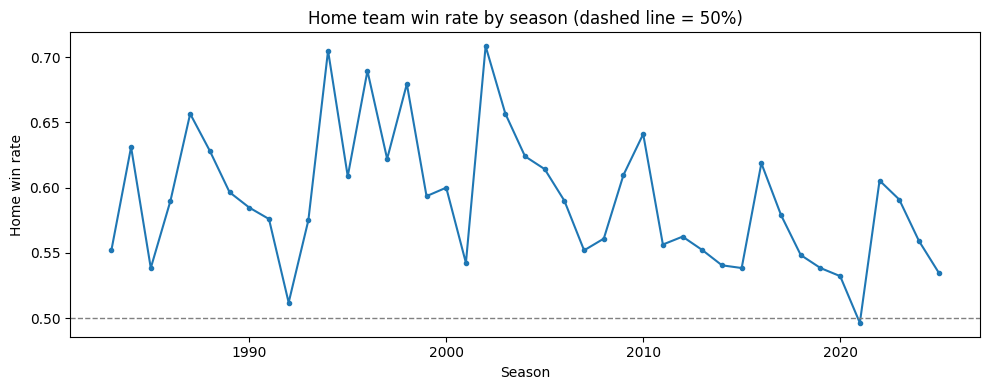

In [9]:
# ---- Home-ground advantage: overall home win rate ----
home_win_rate = (matches['match_result'] == 'Home Win').mean()
print(f"Overall home-team win rate across {len(matches)} matches: {home_win_rate:.1%}")

win_rate_by_year = matches.assign(home_win=(matches['match_result']=='Home Win').astype(int)) \
                           .groupby('year')['home_win'].mean()

plt.figure(figsize=(10,4))
plt.plot(win_rate_by_year.index, win_rate_by_year.values, marker='o', ms=3)
plt.axhline(0.5, color='grey', linestyle='--', linewidth=1)
plt.title('Home team win rate by season (dashed line = 50%)')
plt.xlabel('Season'); plt.ylabel('Home win rate')
plt.tight_layout(); plt.show()


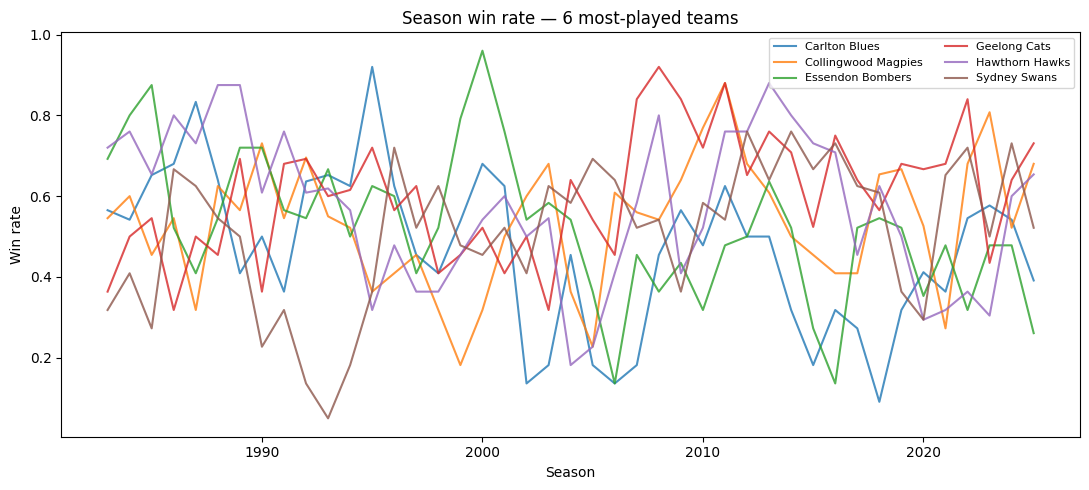

In [10]:
# ---- Team win rate over time (top 6 most-played teams for readability) ----
team_year = pd.concat([
    team_matches.assign(is_win=(team_matches['result']=='W').astype(int))[['team_name','year','is_win']]
])
top_teams = team_year['team_name'].value_counts().head(6).index
pivot = team_year[team_year['team_name'].isin(top_teams)].groupby(['year','team_name'])['is_win'].mean().unstack()

plt.figure(figsize=(11,5))
for t in pivot.columns:
    plt.plot(pivot.index, pivot[t], label=t, alpha=0.8)
plt.legend(fontsize=8, ncol=2)
plt.title('Season win rate — 6 most-played teams')
plt.xlabel('Season'); plt.ylabel('Win rate')
plt.tight_layout(); plt.show()


### 3.2 Player-level distributions for the "top player" metrics


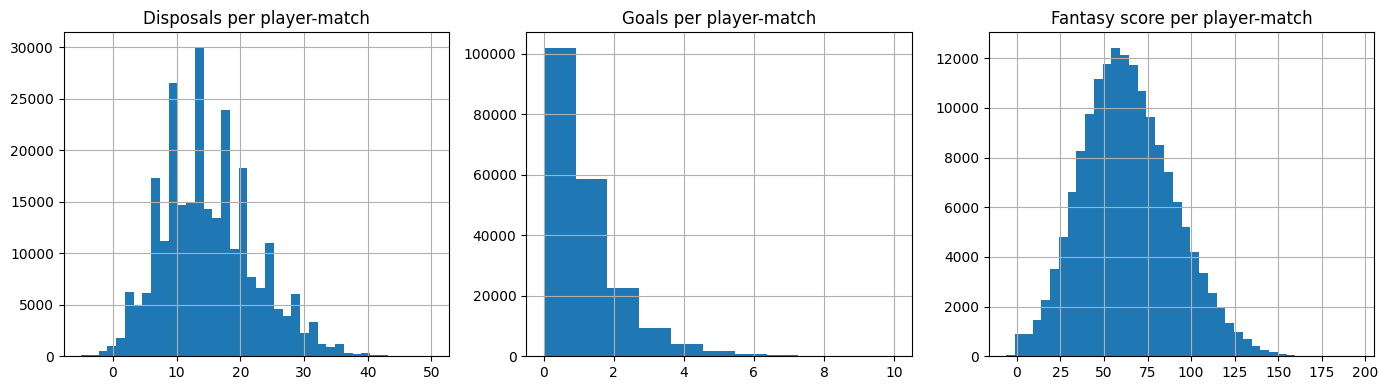

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
round_by_round['disposals'].dropna().clip(upper=50).hist(bins=40, ax=axes[0])
axes[0].set_title('Disposals per player-match')
round_by_round['goals'].dropna().clip(upper=10).hist(bins=11, ax=axes[1])
axes[1].set_title('Goals per player-match')
d['fantasy_score_formula'].clip(upper=200).hist(bins=40, ax=axes[2])
axes[2].set_title('Fantasy score per player-match')
plt.tight_layout(); plt.show()


In [12]:
# ---- Historical leaders (career totals) ----
career = round_by_round.groupby('player_id').agg(
    games=('id','count'), total_disposals=('disposals','sum'), total_goals=('goals','sum')
).merge(players_info[['id','player_name']], left_on='player_id', right_on='id', how='left')

print("Top 10 career disposal-getters in this dataset:")
print(career.sort_values('total_disposals', ascending=False)[['player_name','games','total_disposals']].head(10).to_string(index=False))
print("\nTop 10 career goalkickers in this dataset:")
print(career.sort_values('total_goals', ascending=False)[['player_name','games','total_goals']].head(10).to_string(index=False))


Top 10 career disposal-getters in this dataset:
        player_name  games  total_disposals
   Scott Pendlebury    425          10502.0
      Robert Harvey    383           9267.0
       Brent Harvey    432           8815.0
        Gary Ablett    357           8686.0
       Travis Boak     387           8620.0
      Craig Bradley    375           8571.0
       Joel Selwood    355           8489.0
       Sam Mitchell    329           8335.0
         Scott West    324           8016.0
Patrick Dangerfield    360           7995.0

Top 10 career goalkickers in this dataset:
       player_name  games  total_goals
      Tony Lockett    281       1360.0
    Lance Franklin    354       1066.0
     Matthew Lloyd    270        926.0
Matthew Richardson    282        800.0
       Tom Hawkins    359        796.0
     Jack Riewoldt    347        787.0
     Saverio Rocca    257        748.0
        Barry Hall    289        746.0
   Jeremy Cameron     280        736.0
      Wayne Carey     272        7

In [13]:
# ---- Week-to-week consistency: coefficient of variation of disposals, players with >= 50 games ----
cv = round_by_round.groupby('player_id')['disposals'].agg(['mean','std','count'])
cv = cv[cv['count'] >= 50]
cv['cv'] = cv['std'] / cv['mean']
print("Distribution of week-to-week disposal consistency (lower CV = more consistent), players w/ 50+ games:")
print(cv['cv'].describe().round(2))


Distribution of week-to-week disposal consistency (lower CV = more consistent), players w/ 50+ games:
count    1598.00
mean        0.39
std         0.11
min         0.21
25%         0.33
50%         0.37
75%         0.42
max         2.39
Name: cv, dtype: float64


**Note on position-based splits (forward vs. midfielder vs. defender):** this dataset does **not** contain an
explicit position column — only `jersey_num`, which is not a reliable position proxy in the modern era. Rather than
fabricate a position label, we build a **statistical-profile proxy** (documented, not asserted as ground truth):
high `hit_outs` → ruck, high `rebound_50s` + low `inside_50s` → defender, high `inside_50s` + `goals` → forward,
high `clearances` + `contested_possessions` and balanced up/down-field involvement → midfielder. This is flagged
as a known data gap for Day 2 — if a real position table becomes available it should replace this heuristic.


In [14]:
def role_proxy(row):
    if row['hit_outs_avg'] and row['hit_outs_avg'] > 8:
        return 'Ruck'
    if row['inside_50s_avg'] and row['goals_avg'] and row['inside_50s_avg'] > 3 and row['goals_avg'] > 0.8:
        return 'Forward'
    if row['rebound_50s_avg'] and row['rebound_50s_avg'] > 3 and (row['inside_50s_avg'] or 0) < 2:
        return 'Defender'
    return 'Midfielder/Other'

prof = round_by_round.groupby('player_id')[['hit_outs','inside_50s','goals','rebound_50s']].mean()
prof.columns = [c + '_avg' for c in prof.columns]
prof['role_proxy'] = prof.apply(role_proxy, axis=1)
print(prof['role_proxy'].value_counts())


role_proxy
Midfielder/Other    2527
Forward              274
Ruck                 188
Defender             120
Name: count, dtype: int64


### 3.3 Five relationships relevant to prediction


C:\Users\raven\AppData\Local\Temp\ipykernel_5560\3661911127.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  form_plot = tmw.groupby(form_bins)['is_win'].mean()


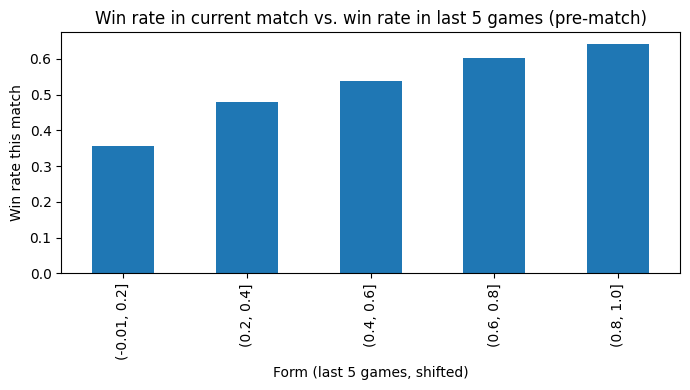

In [15]:
# (1) Recent form (last-5-game win rate) vs win probability in the next match — built properly in Task 4,
#     quick illustrative version here using a simple shifted rolling mean per team.
tmw = team_matches.sort_values(['team_name', 'match_date']).copy()
tmw['is_win'] = (tmw['result'] == 'W').astype(int)
tmw['form_last5'] = tmw.groupby('team_name')['is_win'].transform(lambda s: s.shift(1).rolling(5, min_periods=3).mean())
form_bins = pd.cut(tmw['form_last5'], bins=[-0.01,0.2,0.4,0.6,0.8,1.0])
form_plot = tmw.groupby(form_bins)['is_win'].mean()

plt.figure(figsize=(7,4))
form_plot.plot(kind='bar')
plt.title('Win rate in current match vs. win rate in last 5 games (pre-match)')
plt.ylabel('Win rate this match'); plt.xlabel('Form (last 5 games, shifted)')
plt.tight_layout(); plt.show()


C:\Users\raven\AppData\Local\Temp\ipykernel_5560\819425986.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  venue_home_adv = matches.groupby('venue').apply(


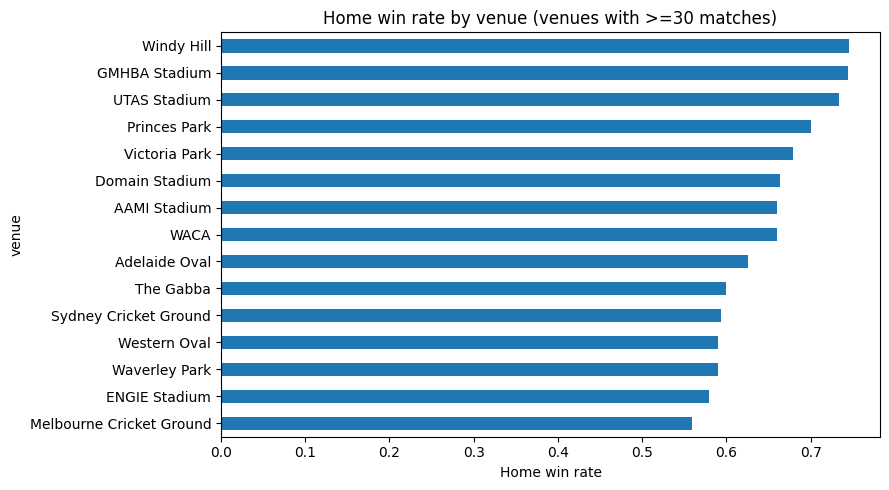

In [16]:
# (2) Home-ground advantage by venue
venue_home_adv = matches.groupby('venue').apply(
    lambda d: (d['match_result']=='Home Win').mean()
).sort_values(ascending=False)
venue_counts = matches['venue'].value_counts()
venue_home_adv = venue_home_adv[venue_counts[venue_home_adv.index] >= 30]

plt.figure(figsize=(9,5))
venue_home_adv.head(15).plot(kind='barh')
plt.title('Home win rate by venue (venues with >=30 matches)')
plt.xlabel('Home win rate'); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()


C:\Users\raven\AppData\Local\Temp\ipykernel_5560\2826737653.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rest_plot = tmw.groupby(rest_bins)['is_win'].mean()


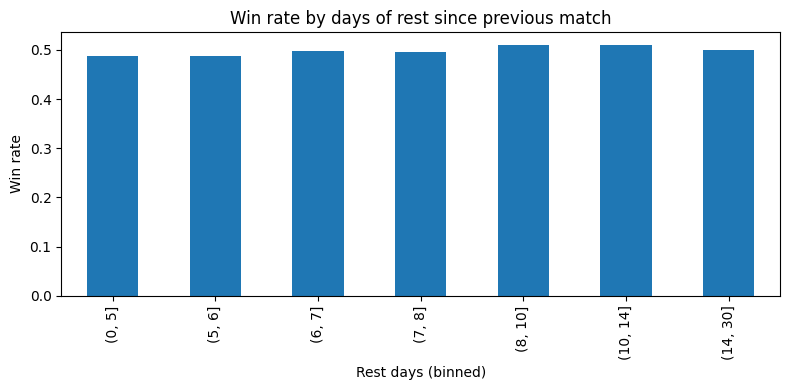

In [17]:
# (3) Rest days between matches vs win rate
tmw['prev_date'] = tmw.groupby('team_name')['match_date'].shift(1)
tmw['rest_days'] = (tmw['match_date'] - tmw['prev_date']).dt.days
rest_bins = pd.cut(tmw['rest_days'], bins=[0,5,6,7,8,10,14,30])
rest_plot = tmw.groupby(rest_bins)['is_win'].mean()

plt.figure(figsize=(8,4))
rest_plot.plot(kind='bar')
plt.title('Win rate by days of rest since previous match')
plt.ylabel('Win rate'); plt.xlabel('Rest days (binned)')
plt.tight_layout(); plt.show()


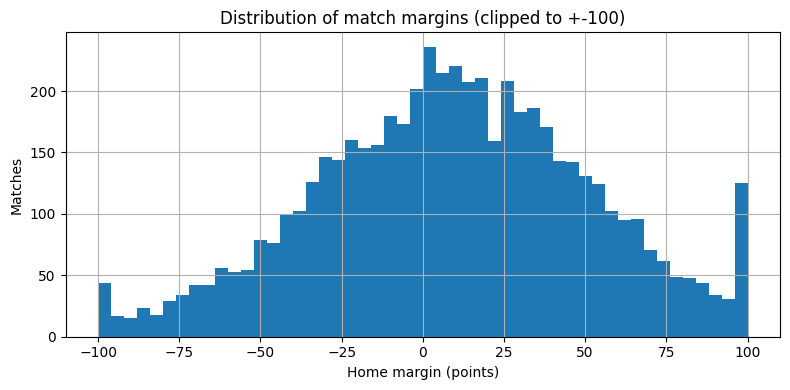

Share of matches decided by <= 12 points (~2 goals): 0.23


In [18]:
# (4) Score margin distribution — how noisy/close matches typically are
plt.figure(figsize=(8,4))
matches['match_margin'].clip(-100,100).hist(bins=50)
plt.title('Distribution of match margins (clipped to +-100)')
plt.xlabel('Home margin (points)'); plt.ylabel('Matches')
plt.tight_layout(); plt.show()
print("Share of matches decided by <= 12 points (~2 goals):",
      (matches['match_margin'].abs() <= 12).mean().round(3))


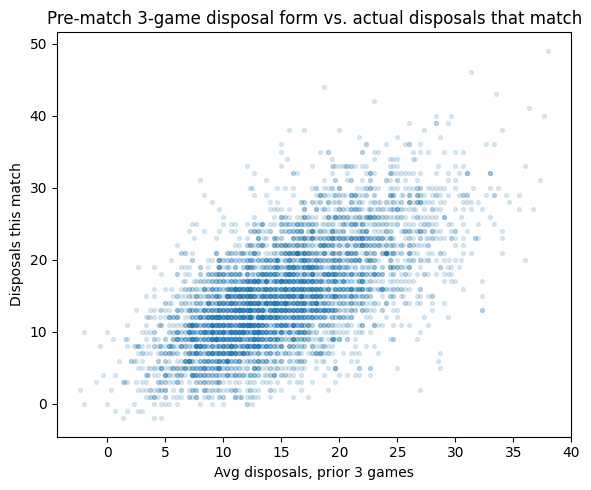

Correlation: 0.653


In [19]:
# (5) Player recent form vs next-match output (disposals) — illustrates why "last-N-games" features matter
rbr_sorted = round_by_round.sort_values(['player_id','match_date']).copy()
rbr_sorted['disposals_form3'] = rbr_sorted.groupby('player_id')['disposals'].transform(
    lambda s: s.shift(1).rolling(3, min_periods=2).mean())

sample = rbr_sorted.dropna(subset=['disposals_form3','disposals'])
plt.figure(figsize=(6,5))
plt.scatter(sample['disposals_form3'].sample(5000, random_state=1),
            sample.loc[sample['disposals_form3'].sample(5000, random_state=1).index, 'disposals'],
            alpha=0.15, s=8)
plt.title('Pre-match 3-game disposal form vs. actual disposals that match')
plt.xlabel('Avg disposals, prior 3 games'); plt.ylabel('Disposals this match')
plt.tight_layout(); plt.show()
print("Correlation:", sample['disposals_form3'].corr(sample['disposals']).round(3))


## Task 4 — Feature Engineering for Prediction

**Leakage rule used throughout:** every rolling/form feature is computed with `.shift(1)` before the rolling
window, so the feature for a given match only uses information from **strictly earlier** matches. Nothing about
the match being predicted (its own score, its own result) ever appears on the right-hand side of a feature.

### 4.1 Team-level rolling/form features


In [20]:
team_long = team_matches.sort_values(['team_name', 'match_date']).copy()
team_long['is_win'] = (team_long['result'] == 'W').astype(int)

def add_team_rolling(df, n):
    df[f'win_rate_last{n}'] = df.groupby('team_name')['is_win'].transform(
        lambda s: s.shift(1).rolling(n, min_periods=1).mean())
    df[f'avg_score_for_last{n}'] = df.groupby('team_name')['team_score'].transform(
        lambda s: s.shift(1).rolling(n, min_periods=1).mean())
    df[f'avg_score_against_last{n}'] = df.groupby('team_name')['opponent_score'].transform(
        lambda s: s.shift(1).rolling(n, min_periods=1).mean())
    return df

for n in (3, 5, 10):
    team_long = add_team_rolling(team_long, n)

# Win streak: consecutive wins immediately prior to this match
def win_streak(s):
    streak, out = 0, []
    for v in s.shift(1):
        if pd.isna(v):
            out.append(np.nan); streak = 0
        elif v == 1:
            streak += 1; out.append(streak)
        else:
            streak = 0; out.append(0)
    return pd.Series(out, index=s.index)

team_long['win_streak'] = team_long.groupby('team_name')['is_win'].transform(win_streak)

# Rest days (built in EDA step, recompute here so this section stands alone)
team_long['prev_date'] = team_long.groupby('team_name')['match_date'].shift(1)
team_long['rest_days'] = (team_long['match_date'] - team_long['prev_date']).dt.days

team_long[['team_name','match_date','win_rate_last5','avg_score_for_last5',
           'avg_score_against_last5','win_streak','rest_days']].tail(8)


,team_name,match_date,win_rate_last5,avg_score_for_last5,avg_score_against_last5,win_streak,rest_days
553,Western Bulldogs,2025-07-03,0.6,108.8,84.0,3.0,6.0
1408,Western Bulldogs,2025-07-12,0.8,113.0,75.6,4.0,9.0
554,Western Bulldogs,2025-07-18,0.8,120.8,81.2,0.0,6.0
1420,Western Bulldogs,2025-07-25,0.6,109.6,86.4,0.0,7.0
555,Western Bulldogs,2025-07-31,0.6,111.2,85.2,1.0,6.0
556,Western Bulldogs,2025-08-10,0.6,116.6,74.8,2.0,10.0
557,Western Bulldogs,2025-08-17,0.6,110.8,77.6,3.0,7.0
558,Western Bulldogs,2025-08-24,0.8,116.4,62.2,4.0,7.0


### 4.2 Ladder position at time of match (season-to-date, pre-match)


In [21]:
def ladder_points(result):
    return {'W': 4, 'D': 2, 'L': 0}.get(result, 0)

team_long['ladder_pts_match'] = team_long['result'].map(ladder_points)
team_long = team_long.sort_values(['year','team_name','match_date'])
team_long['ladder_pts_cum_pre'] = team_long.groupby(['year','team_name'])['ladder_pts_match'].transform(
    lambda s: s.shift(1).cumsum().fillna(0))

# Rank within season, as of just before this match (pre-match ladder position)
def rank_pre_match(df):
    df = df.copy()
    ranks = df.groupby('match_date')['ladder_pts_cum_pre'].rank(ascending=False, method='min')
    return ranks

team_long['ladder_rank_pre'] = team_long.groupby('year', group_keys=False).apply(
    lambda d: d.groupby('match_date')['ladder_pts_cum_pre'].rank(ascending=False, method='min')
)
team_long[['team_name','year','match_date','ladder_pts_cum_pre','ladder_rank_pre']].tail(6)


C:\Users\raven\AppData\Local\Temp\ipykernel_5560\1781890160.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_long['ladder_rank_pre'] = team_long.groupby('year', group_keys=False).apply(


,team_name,year,match_date,ladder_pts_cum_pre,ladder_rank_pre
554,Western Bulldogs,2025,2025-07-18,40.0,2.0
1420,Western Bulldogs,2025,2025-07-25,40.0,2.0
555,Western Bulldogs,2025,2025-07-31,44.0,2.0
556,Western Bulldogs,2025,2025-08-10,48.0,3.0
557,Western Bulldogs,2025,2025-08-17,52.0,2.0
558,Western Bulldogs,2025,2025-08-24,56.0,5.0


### 4.3 Head-to-head and venue features


In [22]:
def add_h2h(df):
    df = df.sort_values(['team_name','opponent','match_date']).copy()
    df['h2h_win_rate_prior'] = df.groupby(['team_name','opponent'])['is_win'].transform(
        lambda s: s.shift(1).expanding().mean())
    df['h2h_games_played_prior'] = df.groupby(['team_name','opponent'])['is_win'].cumcount()
    return df

team_long = add_h2h(team_long)

# Venue familiarity: how many times has this team played at this venue before (pre-match)
team_long = team_long.sort_values(['team_name','venue','match_date'])
team_long['venue_games_prior'] = team_long.groupby(['team_name','venue']).cumcount()
team_long['venue_win_rate_prior'] = team_long.groupby(['team_name','venue'])['is_win'].transform(
    lambda s: s.shift(1).expanding().mean())

team_long.sort_values('match_date').tail(3)[['team_name','opponent','venue',
    'h2h_win_rate_prior','venue_games_prior','venue_win_rate_prior']]


,team_name,opponent,venue,h2h_win_rate_prior,venue_games_prior,venue_win_rate_prior
1359,Brisbane Lions,Collingwood Magpies,Melbourne Cricket Ground,0.545455,65,0.323077
1360,Brisbane Lions,Geelong Cats,Melbourne Cricket Ground,0.400000,66,0.333333
4136,Geelong Cats,Brisbane Lions,Melbourne Cricket Ground,0.571429,219,0.607306


### 4.4 Player-level rolling form features


In [23]:
rbr = round_by_round.sort_values(['player_id','match_date']).copy()
for stat in ('disposals','goals'):
    for n in (3, 5, 10):
        rbr[f'{stat}_avg_last{n}'] = rbr.groupby('player_id')[stat].transform(
            lambda s, n=n: s.shift(1).rolling(n, min_periods=1).mean())

rbr['fantasy_avg_last5'] = rbr.groupby('player_id')['fantasy_points'].transform(
    lambda s: s.shift(1).rolling(5, min_periods=1).mean())

rbr[['player_id','team','match_date','disposals_avg_last5','goals_avg_last5','fantasy_avg_last5']].tail(6)


,player_id,team,match_date,disposals_avg_last5,goals_avg_last5,fantasy_avg_last5
259648,46373,Carlton Blues,2007-05-19,11.50,1.0,45.5
259646,46373,Carlton Blues,2007-06-30,11.00,1.0,42.0
259647,46373,Carlton Blues,2007-07-08,11.25,1.5,47.0
259650,46373,Carlton Blues,2007-07-15,11.40,1.5,52.8
259642,46374,Adelaide Crows,2010-04-04,NaN,NaN,NaN
273695,46374,Adelaide Crows,2010-08-21,10.00,NaN,36.0


### 4.5 Assemble the match-level feature table and save (versioned)

This merges the home team's pre-match features and the away team's pre-match features onto the
`matches` table built in Task 2, producing one wide row per match — this is what Day 2's match-winner model
will load directly.


In [24]:
feature_cols = ['win_rate_last3','win_rate_last5','win_rate_last10',
                'avg_score_for_last5','avg_score_against_last5',
                'win_streak','rest_days','ladder_pts_cum_pre','ladder_rank_pre',
                'h2h_win_rate_prior','h2h_games_played_prior',
                'venue_games_prior','venue_win_rate_prior']

home_feat = team_long[team_long['home_away']=='H'][['match_id'] + feature_cols].add_prefix('home_').rename(columns={'home_match_id':'match_id'})
away_feat = team_long[team_long['home_away']=='A'][['match_id'] + feature_cols].add_prefix('away_').rename(columns={'away_match_id':'match_id'})

feature_table = matches.merge(home_feat, on='match_id', how='left').merge(away_feat, on='match_id', how='left')

print(feature_table.shape)
feature_table.head()


(5517, 38)


,match_id,year,round,match_date,venue,crowd,home_team,away_team,home_score,away_score,match_margin,match_result,home_win_rate_last3,home_win_rate_last5,home_win_rate_last10,home_avg_score_for_last5,home_avg_score_against_last5,home_win_streak,home_rest_days,home_ladder_pts_cum_pre,home_ladder_rank_pre,home_h2h_win_rate_prior,home_h2h_games_played_prior,home_venue_games_prior,home_venue_win_rate_prior,away_win_rate_last3,away_win_rate_last5,away_win_rate_last10,away_avg_score_for_last5,away_avg_score_against_last5,away_win_streak,away_rest_days,away_ladder_pts_cum_pre,away_ladder_rank_pre,away_h2h_win_rate_prior,away_h2h_games_played_prior,away_venue_games_prior,away_venue_win_rate_prior
0,1983-03-26__Princes Park__Carlton Blues__Richm...,1983,1,1983-03-26,Princes Park,28498.0,Carlton Blues,Richmond Tigers,136,76,60,Home Win,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,0,0,NaN
1,1983-03-26__Melbourne Cricket Ground__Collingw...,1983,1,1983-03-26,Melbourne Cricket Ground,72274.0,Melbourne Demons,Collingwood Magpies,125,135,-10,Away Win,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,0,0,NaN
2,1983-03-27__Sydney Cricket Ground__Essendon Bo...,1983,1,1983-03-27,Sydney Cricket Ground,11916.0,Sydney Swans,Essendon Bombers,111,110,1,Home Win,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,0,0,NaN
3,1983-04-02__Western Oval__Carlton Blues__Weste...,1983,2,1983-04-02,Western Oval,20414.0,Western Bulldogs,Carlton Blues,99,82,17,Home Win,0.0,0.0,0.0,75.0,106.0,0.0,7.0,0.0,4.0,NaN,0,0,NaN,1.0,1.0,1.0,136.0,76.0,1.0,7.0,4.0,1.0,NaN,0,0,NaN
4,1983-04-02__Victoria Park__Collingwood Magpies...,1983,2,1983-04-02,Victoria Park,34751.0,Collingwood Magpies,Geelong Cats,96,101,-5,Away Win,1.0,1.0,1.0,135.0,125.0,1.0,7.0,4.0,1.0,NaN,0,0,NaN,1.0,1.0,1.0,106.0,75.0,1.0,7.0,4.0,1.0,NaN,0,0,NaN


In [25]:
import datetime as dt

OUTPUT_DIR = "feature_store"
os.makedirs(OUTPUT_DIR, exist_ok=True)
VERSION = dt.date.today().isoformat()  # e.g. 2026-09-14 -- bump / pin this manually for a frozen release

feature_table_path = os.path.join(OUTPUT_DIR, f"match_feature_table_v{VERSION}.csv")
feature_table.to_csv(feature_table_path, index=False)

player_feature_cols = ['player_id','team','match_date','year','round',
                        'disposals_avg_last3','disposals_avg_last5','disposals_avg_last10',
                        'goals_avg_last3','goals_avg_last5','goals_avg_last10','fantasy_avg_last5']
player_feature_path = os.path.join(OUTPUT_DIR, f"player_feature_table_v{VERSION}.csv")
rbr[player_feature_cols].to_csv(player_feature_path, index=False)

print("Saved:", feature_table_path)
print("Saved:", player_feature_path)


Saved: feature_store\match_feature_table_v2026-09-14.csv
Saved: feature_store\player_feature_table_v2026-09-14.csv


### 4.6 Feature dictionary

| Feature | Description | Computation window | Source column(s) |
|---|---|---|---|
| `win_rate_last{3,5,10}` | Team win rate over its last N matches, **excluding** the match being predicted | rolling N, shifted 1 | `team_matches.result` |
| `avg_score_for_last5` / `avg_score_against_last5` | Avg points scored / conceded over last 5 matches | rolling 5, shifted 1 | `team_score`, `opponent_score` |
| `win_streak` | Consecutive wins immediately before this match (resets on a loss/draw) | expanding, shifted 1 | `result` |
| `rest_days` | Days since the team's previous match | diff of `match_date` per team | `match_date` |
| `ladder_pts_cum_pre` | Cumulative ladder points (4/2/0) this season, before this match | expanding sum within season, shifted 1 | `result`, `year` |
| `ladder_rank_pre` | Rank among all teams by `ladder_pts_cum_pre` at this point in the season | cross-sectional rank per match date | derived |
| `h2h_win_rate_prior` | Win rate specifically against this opponent, in all prior meetings | expanding, shifted 1, grouped by (team, opponent) | `result` |
| `h2h_games_played_prior` | Number of prior meetings against this opponent | cumulative count | derived |
| `venue_games_prior` / `venue_win_rate_prior` | Team's experience/win rate at this specific venue, before this match | expanding, shifted 1, grouped by (team, venue) | `venue`, `result` |
| `disposals_avg_last{3,5,10}` (player) | Player's average disposals over last N games | rolling N, shifted 1 | `disposals` |
| `goals_avg_last{3,5,10}` (player) | Player's average goals over last N games | rolling N, shifted 1 | `goals` |
| `fantasy_avg_last5` (player) | Player's average fantasy score over last 5 games | rolling 5, shifted 1 | `fantasy_points` |

Every feature above is versioned by the `VERSION` string (today's date) baked into the output filename — bump it
manually when you want to freeze a release that later models pin to.


## Task 5 — Reproducible Train/Hold-Out Split

**Why a random split would leak the future:** in a time-series sports context, a match's rolling/form/ladder
features are functions of everything that happened *before* it, and the season's outcomes are also serially
correlated (a team's true strength this month influences several consecutive matches). A random 80/20 split
would put some early-season matches in the test set while later matches from the *same season and same teams*
sit in the training set — so the model could implicitly learn from a team's future-season trajectory (e.g. it
finished top-4 that year) when predicting an earlier match. Time-based splitting guarantees the model only ever
trains on the genuine past relative to what it's evaluated on, exactly matching how it would be deployed
(predicting an upcoming round having only seen prior rounds).

### Reusable split function


In [26]:
def time_based_split(df, date_col='match_date', holdout_seasons=1, holdout_start_year=None):
    """
    Split a match/player-match dataframe into train and holdout sets using only past-vs-future logic.

    Parameters
    ----------
    df : DataFrame containing a 'year' column and a date_col.
    holdout_seasons : int, number of most-recent seasons to hold out (ignored if holdout_start_year given).
    holdout_start_year : int, optional explicit first year of the holdout set.

    Returns
    -------
    train_df, holdout_df
    """
    years = sorted(df['year'].unique())
    if holdout_start_year is None:
        holdout_start_year = years[-holdout_seasons]
    train_df = df[df['year'] < holdout_start_year].copy()
    holdout_df = df[df['year'] >= holdout_start_year].copy()
    return train_df, holdout_df

train_matches, holdout_matches = time_based_split(feature_table, holdout_seasons=1)
print(f"Train: {len(train_matches)} matches, seasons {train_matches['year'].min()}-{train_matches['year'].max()}")
print(f"Holdout: {len(holdout_matches)} matches, season(s) {sorted(holdout_matches['year'].unique())}")


Train: 5360 matches, seasons 1983-2024
Holdout: 157 matches, season(s) [np.int64(2025)]


### What's a realistic accuracy ceiling here?

Published AFL match-prediction work and betting-market benchmarks generally land match-winner classifiers in the
roughly **65-72% accuracy** range once reasonable pre-match features (form, ladder position, home ground) are
used — only modestly above the naive "always pick the home team" baseline of about 57-60% observed in this
dataset. Player-level "top disposals/goals" prediction is noisier still, since a single match's output depends on
tagging decisions, weather, and in-game role changes that aren't fully captured pre-match. Sports outcomes have a
large genuinely-random component (injuries mid-game, umpiring decisions, a gust of wind on a set shot), so no
amount of feature engineering removes that floor. If a model on this kind of holdout ever reports accuracy in the
90%+ range, that is a **red flag for leakage** (e.g. a feature that accidentally includes same-match information,
or a train/test split that let future data bleed backward) rather than a genuine breakthrough — real-world sports
betting markets, which have enormous financial incentive to be accurate, still don't clear that bar.
